PCA

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from factor_analyzer import calculate_bartlett_sphericity, calculate_kmo



df_movies_clean = pd.read_csv('movies_data_clean.csv', encoding='utf-8', encoding_errors='ignore')

X = df_movies_clean.select_dtypes(include=[np.number]).copy()

X = X.dropna()


Matriz de Correlación 

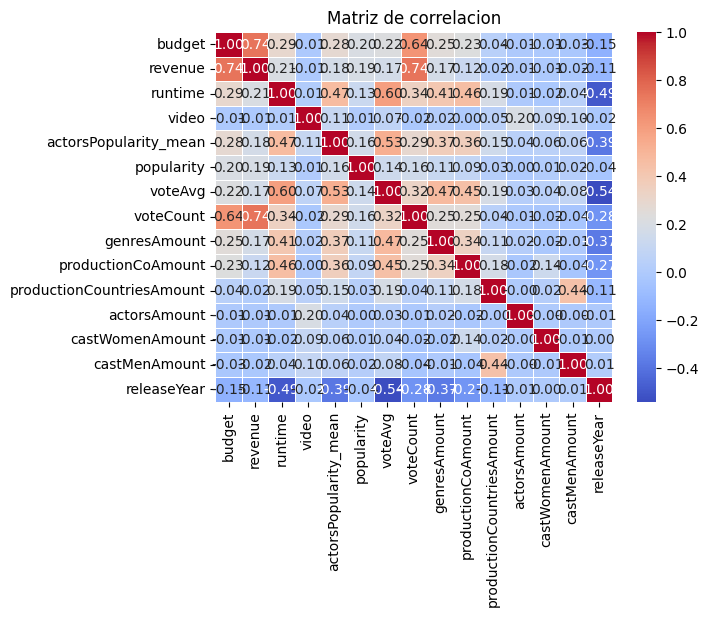

In [26]:
corr = X.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlacion")
plt.show()

La matriz de correlación muestra la existencia de correlaciones moderadas y fuertes entre varias variables, particularmente entre budget, revenue y voteCount, lo cual sugiere la presencia de un factor común relacionado con el éxito comercial de las películas. Asimismo, se observan correlaciones negativas entre releaseYear y variables como voteAvg y runtime, lo que podría reflejar cambios estructurales en la industria cinematográfica a lo largo del tiempo. Se puede  observar que la matriz no es cercana a la identidad y presenta bloques de variables relacionadas. 

Analisis Viabilidad

In [27]:
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

chi_sq, p = calculate_bartlett_sphericity(Xz)
print(f'Chi-Square: {chi_sq:.5f}, p-value: {p:.6f}')

kmo_all, kmo_model = calculate_kmo(Xz)
print(f"KMO: {kmo_model:.5f}")

media= Xz.mean(axis=0)
desviacion = Xz.std(axis=0)

print(f"Medias: {media}")
print(f"Desviaciones estándar: {desviacion}")

Chi-Square: 84913.71070, p-value: 0.000000
KMO: 0.80313
Medias: [-9.14846554e-17  0.00000000e+00  0.00000000e+00  5.71779096e-18
 -4.57423277e-17 -1.14355819e-17 -1.82969311e-16  2.28711639e-17
 -4.57423277e-17 -9.14846554e-17  2.28711639e-17  1.42944774e-17
 -1.14355819e-17 -1.14355819e-17 -7.54748407e-15]
Desviaciones estándar: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


A partir de estos resultados se observa que el valor de p es < 0.05, lo que indica que se puede rechazar la hipótesis nula que dice que la matríz de correlación es identidad. De igual forma se obtuvo el coeficiente KMO, el cual dio un valo de 0.80313, lo  que significa que las variables comparten suficiente varianza común. Dados estos resultados y por la matriz de correlación, se puede concluir que si es adecuado aplicar PCA a este conjunto de datos.

PCA

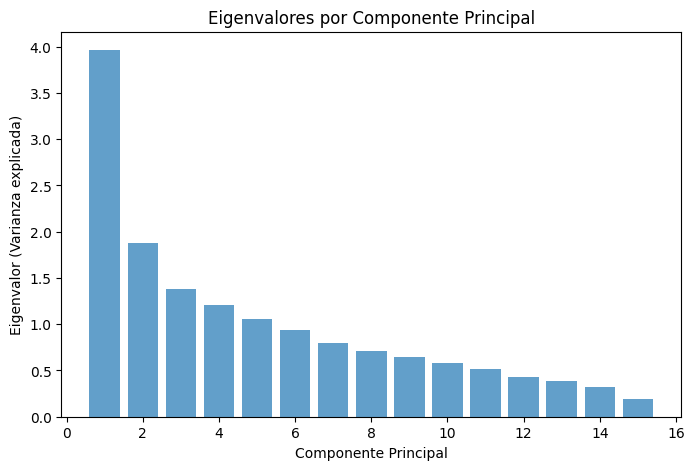

Componente  Eigenvalor  Proporcion_varianza (%)
       PC1      3.9634                    26.42
       PC2      1.8791                    12.53
       PC3      1.3794                     9.20
       PC4      1.2075                     8.05
       PC5      1.0539                     7.03
       PC6      0.9416                     6.28
       PC7      0.7976                     5.32
       PC8      0.7055                     4.70
       PC9      0.6426                     4.28
      PC10      0.5813                     3.88
      PC11      0.5165                     3.44
      PC12      0.4306                     2.87
      PC13      0.3817                     2.54
      PC14      0.3239                     2.16
      PC15      0.1963                     1.31

Componentes con eigenvalor > 1: 5


In [34]:
pca_todo = PCA()
pca_todo.fit(Xz)

eigenvalues = pca_todo.explained_variance_

explained = pca_todo.explained_variance_ratio_

n_vars = len(X.columns)

plt.figure(figsize=(8,5))
plt.bar(range(1, n_vars + 1), eigenvalues, alpha=0.7)
plt.title("Eigenvalores por Componente Principal")
plt.xlabel("Componente Principal")
plt.ylabel("Eigenvalor (Varianza explicada)")
plt.show()


varianza_df = pd.DataFrame({
    'Componente' : [f'PC{i+1}' for i in range(n_vars)],
    'Eigenvalor' : np.round(eigenvalues, 4),
    'Proporcion_varianza (%)' : np.round(explained * 100, 2)
})

print(varianza_df.to_string(index=False))


n_componentes = sum(eigenvalues > 1)
print(f"\nComponentes con eigenvalor > 1: {n_componentes}")


Para poder explicar la mayor variabilidad se utilizarán 5 componentes puesto que se muestra que son 5 los componentes cuyos eigenvalores son mayores a 1, lo que indica que cada uno explica más varianza que una variable original estandarizada. El primer componente principal explica el 26.42% de la varianza total, siendo la dirección de máxima variabilidad del conjunto de datos. En total, los primeros 5 componentes explican el 63.22% de la varianza total, lo que nos permite reducir de 15 variables a 5 componentes conservando una proporción significativa de la información. 

PCA Componentes


  PC1 (26.42% varianza):
voteAvg                        0.3767
runtime                        0.3720
voteCount                      0.3427
actorsPopularity_mean          0.3363
budget                         0.3159

  PC2 (12.53% varianza):
revenue                        0.5152
budget                         0.4346
voteCount                      0.3890
productionCountriesAmount      -0.2697
voteAvg                        -0.2583

  PC3 (9.20% varianza):
castMenAmount                  0.6712
productionCountriesAmount      0.5676
video                          0.2211
releaseYear                    0.2037
revenue                        0.1808

  PC4 (8.05% varianza):
video                          0.6463
actorsAmount                   0.6351
castWomenAmount                0.2787
productionCountriesAmount      -0.2185
castMenAmount                  -0.1652

  PC5 (7.03% varianza):
castWomenAmount                0.8413
actorsAmount                   -0.3587
productionCoAmount             0

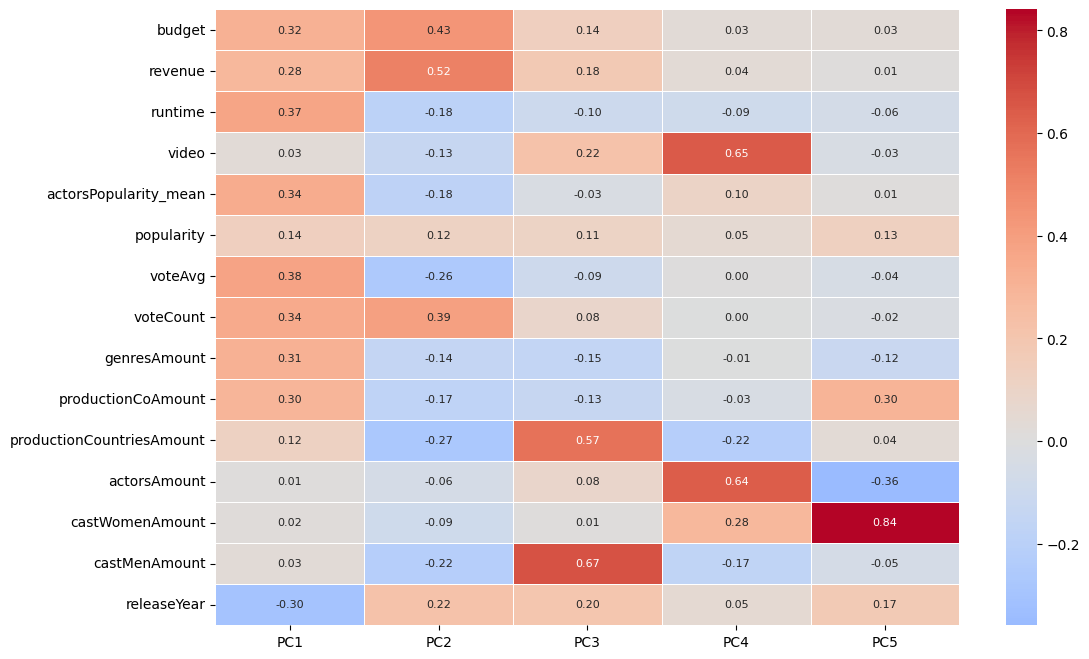

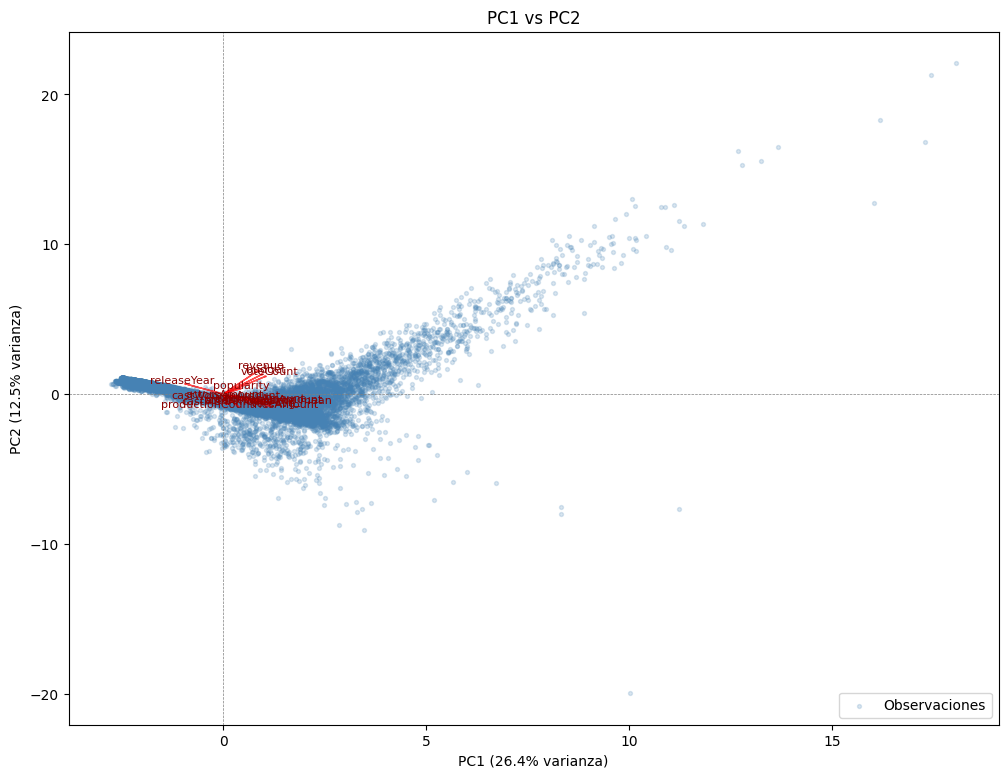

In [35]:
pca = PCA(n_components= n_componentes)
X_pca = pca.fit_transform(Xz)

loadings = pca.components_.T
loadings_df = pd.DataFrame(
    loadings,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(n_componentes)]
)

for i in range(n_componentes):
    col = f"PC{i+1}"
    top5 = loadings_df[col].abs().sort_values(ascending=False).head(5)
    var_exp = pca.explained_variance_ratio_[i] * 100
    print(f"\n  {col} ({var_exp:.2f}% varianza):")
    for var, val in top5.items():
        print(f"{var:<30} {loadings_df.loc[var, col]:.4f}")


plt.figure(figsize=(max(8, 8 * 1.5), len(X.columns) * 0.4 + 2))
sns.heatmap(
    loadings_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, s=8, color='steelblue', label='Observaciones')

scale = 3
for i, var in enumerate(X.columns):
    ax.arrow(
        0, 0,
        loadings[i, 0] * scale,
        loadings[i, 1] * scale,
        head_width=0.05, head_length=0.05,
        fc='red', ec='red', alpha=0.7
    )
    ax.text(
        loadings[i, 0] * scale * 1.1,
        loadings[i, 1] * scale * 1.1,
        var, fontsize=8, color='darkred', ha='center'
    )

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("PC1 vs PC2")
ax.legend()


Como se puede observar, en el primer componente, que significa 26.42% de la varianza total, las variables con mayor carga son voteAvg, runtime, voteCount, actorsPopularity_mean y budget, representando así el impacto integral de la película. Este componente sugiere que existe una dimensión dominante que agrupa calidad, escala y visibilidad. 

El segundo componente, 12.53% sobre la variabilidad total, representa principalmente una dimensión de éxito comercial, pues sus variables con mayor carga son revenue, budget, voteCount, productionCountriesAmount y voteAvg. 

Por otro lado, el tercer componente representa 9.20% de la variabilidad total. Las variables con mayor carga son castMenAmount, productionCountriesAmount, video y release year. Esto representa una dimensión estructural que se puede asociar con la extructura y la expansión internacional de la producción. 

Luego, el cuarto componente, que representa 8.05% de la variabilidad total, tiene video, actorsAmount y castWomenAmount. Y por último, el quinto componente que representa el 7.03%, cuyos atributos principales son castWomenAmount, productionCoAmount, releaseYear. Representa una dimensión de composición de género del reparto y estructura organizacional. Este componente podría ser relevante para analizar tendencias de diversidad en la industria cinematográfica.

